<a href="https://colab.research.google.com/github/juanigr/Ayudantias/blob/main/code/Chinook_db.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Working with the Chinook database

## downloading the database from github

In [1]:
#download the Chinook database
#!pip install SQLAlchemy==1.4.46
!git clone https://github.com/lerocha/chinook-database.git

Cloning into 'chinook-database'...
remote: Enumerating objects: 3019, done.
remote: Counting objects: 100% (266/266), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 3019 (delta 228), reused 196 (delta 191), pack-reused 2753 (from 2)
Receiving objects: 100% (3019/3019), 25.21 MiB | 14.91 MiB/s, done.
Resolving deltas: 100% (2093/2093), done.


In [2]:
!pip install -q "ipython-sql" "prettytable==3.11.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.4 MB/s eta 0:00:00


In [3]:
# load the SQL magic extension
# https://github.com/catherinedevlin/ipython-sql
# this extension allows us to connect to DBs and issue SQL command
%load_ext sql
# now we can use the magic extension to connect to our SQLite DB
# use %sql to write an inline SQL command
# use %%sql to write SQL commands in a cell
%sql sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite

## getting information from the Chinook database

We get information about the database engine



In [4]:
%%sql
SELECT sqlite_version();

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


sqlite_version()
3.37.2


We are using [SQLite](https://www.sqlite.org/index.html) 3.22. It's a fast Relational Database engine writing in C. SQLite DB is self-contained: one database is just a file.  SQLite is the most used DB engine in the world. It's built into millions of mobile phones.

### Display tables of the Chinook database


In [5]:
%%sql
SELECT * FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


type,name,tbl_name,rootpage,sql
table,Album,Album,2,"CREATE TABLE [Album]( [AlbumId] INTEGER NOT NULL, [Title] NVARCHAR(160) NOT NULL, [ArtistId] INTEGER NOT NULL, CONSTRAINT [PK_Album] PRIMARY KEY ([AlbumId]), FOREIGN KEY ([ArtistId]) REFERENCES [Artist] ([ArtistId]) ON DELETE NO ACTION ON UPDATE NO ACTION)"
table,Artist,Artist,3,"CREATE TABLE [Artist]( [ArtistId] INTEGER NOT NULL, [Name] NVARCHAR(120), CONSTRAINT [PK_Artist] PRIMARY KEY ([ArtistId]))"
table,Customer,Customer,4,"CREATE TABLE [Customer]( [CustomerId] INTEGER NOT NULL, [FirstName] NVARCHAR(40) NOT NULL, [LastName] NVARCHAR(20) NOT NULL, [Company] NVARCHAR(80), [Address] NVARCHAR(70), [City] NVARCHAR(40), [State] NVARCHAR(40), [Country] NVARCHAR(40), [PostalCode] NVARCHAR(10), [Phone] NVARCHAR(24), [Fax] NVARCHAR(24), [Email] NVARCHAR(60) NOT NULL, [SupportRepId] INTEGER, CONSTRAINT [PK_Customer] PRIMARY KEY ([CustomerId]), FOREIGN KEY ([SupportRepId]) REFERENCES [Employee] ([EmployeeId]) ON DELETE NO ACTION ON UPDATE NO ACTION)"
table,Employee,Employee,5,"CREATE TABLE [Employee]( [EmployeeId] INTEGER NOT NULL, [LastName] NVARCHAR(20) NOT NULL, [FirstName] NVARCHAR(20) NOT NULL, [Title] NVARCHAR(30), [ReportsTo] INTEGER, [BirthDate] DATETIME, [HireDate] DATETIME, [Address] NVARCHAR(70), [City] NVARCHAR(40), [State] NVARCHAR(40), [Country] NVARCHAR(40), [PostalCode] NVARCHAR(10), [Phone] NVARCHAR(24), [Fax] NVARCHAR(24), [Email] NVARCHAR(60), CONSTRAINT [PK_Employee] PRIMARY KEY ([EmployeeId]), FOREIGN KEY ([ReportsTo]) REFERENCES [Employee] ([EmployeeId]) ON DELETE NO ACTION ON UPDATE NO ACTION)"
table,Genre,Genre,6,"CREATE TABLE [Genre]( [GenreId] INTEGER NOT NULL, [Name] NVARCHAR(120), CONSTRAINT [PK_Genre] PRIMARY KEY ([GenreId]))"
table,Invoice,Invoice,7,"CREATE TABLE [Invoice]( [InvoiceId] INTEGER NOT NULL, [CustomerId] INTEGER NOT NULL, [InvoiceDate] DATETIME NOT NULL, [BillingAddress] NVARCHAR(70), [BillingCity] NVARCHAR(40), [BillingState] NVARCHAR(40), [BillingCountry] NVARCHAR(40), [BillingPostalCode] NVARCHAR(10), [Total] NUMERIC(10,2) NOT NULL, CONSTRAINT [PK_Invoice] PRIMARY KEY ([InvoiceId]), FOREIGN KEY ([CustomerId]) REFERENCES [Customer] ([CustomerId]) ON DELETE NO ACTION ON UPDATE NO ACTION)"
table,InvoiceLine,InvoiceLine,8,"CREATE TABLE [InvoiceLine]( [InvoiceLineId] INTEGER NOT NULL, [InvoiceId] INTEGER NOT NULL, [TrackId] INTEGER NOT NULL, [UnitPrice] NUMERIC(10,2) NOT NULL, [Quantity] INTEGER NOT NULL, CONSTRAINT [PK_InvoiceLine] PRIMARY KEY ([InvoiceLineId]), FOREIGN KEY ([InvoiceId]) REFERENCES [Invoice] ([InvoiceId]) ON DELETE NO ACTION ON UPDATE NO ACTION, FOREIGN KEY ([TrackId]) REFERENCES [Track] ([TrackId]) ON DELETE NO ACTION ON UPDATE NO ACTION)"
table,MediaType,MediaType,9,"CREATE TABLE [MediaType]( [MediaTypeId] INTEGER NOT NULL, [Name] NVARCHAR(120), CONSTRAINT [PK_MediaType] PRIMARY KEY ([MediaTypeId]))"
table,Playlist,Playlist,10,"CREATE TABLE [Playlist]( [PlaylistId] INTEGER NOT NULL, [Name] NVARCHAR(120), CONSTRAINT [PK_Playlist] PRIMARY KEY ([PlaylistId]))"
table,PlaylistTrack,PlaylistTrack,11,"CREATE TABLE [PlaylistTrack]( [PlaylistId] INTEGER NOT NULL, [TrackId] INTEGER NOT NULL, CONSTRAINT [PK_PlaylistTrack] PRIMARY KEY ([PlaylistId], [TrackId]), FOREIGN KEY ([PlaylistId]) REFERENCES [Playlist] ([PlaylistId]) ON DELETE NO ACTION ON UPDATE NO ACTION, FOREIGN KEY ([TrackId]) REFERENCES [Track] ([TrackId]) ON DELETE NO ACTION ON UPDATE NO ACTION)"


getting information about a particular table


In [6]:
%%sql
PRAGMA table_info([Track]);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


cid,name,type,notnull,dflt_value,pk
0,TrackId,INTEGER,1,None,1
1,Name,NVARCHAR(200),1,None,0
2,AlbumId,INTEGER,0,None,0
3,MediaTypeId,INTEGER,1,None,0
4,GenreId,INTEGER,0,None,0
5,Composer,NVARCHAR(220),0,None,0
6,Milliseconds,INTEGER,1,None,0
7,Bytes,INTEGER,0,None,0
8,UnitPrice,"NUMERIC(10,2)",1,None,0


In [84]:
# album con menos de 3 canciones, mostrando el nombre del album

%%sql

select
    Album.AlbumId,
    Album.Title as nombre_album,
    count(*) as cantidad_canciones
from Track
join Album using (AlbumId)
group by Album.AlbumId
having cantidad_canciones < 6
order by cantidad_canciones;




 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,nombre_album,cantidad_canciones
2,Balls to the Wall,1
170,Bark at the Moon (Remastered),1
172,Diary of a Madman (Remastered),1
226,Battlestar Galactica: The Story So Far,1
252,Un-Led-Ed,1
254,Aquaman,1
260,Cake: B-Sides and Rarities,1
266,Duos II,1
267,Worlds,1
268,The Best of Beethoven,1


In [91]:
# album con al menos 10 canciones, mostrando el artista del album, tambien el nombre del album.

%%sql

select
album.albumid,
album.title as nombre_album,
Artist.ArtistId,
Artist.Name as nombre_artista,
count(Track.TrackId) as cantidad_canciones
from album
join artist using (Artistid)
join Track using (AlbumId)
group by Album.Albumid
having cantidad_canciones >15
order by cantidad_canciones;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,nombre_album,ArtistId,nombre_artista,cantidad_canciones
67,Vault: Def Leppard's Greatest Hits,78,Def Leppard,16
84,Roda De Funk,86,Funk Como Le Gusta,16
91,Use Your Illusion I,88,Guns N' Roses,16
125,Living After Midnight,98,Judas Priest,16
140,Mais Do Mesmo,99,Legião Urbana,16
149,Garage Inc. (Disc 2),50,Metallica,16
169,Arquivo Os Paralamas Do Sucesso,113,Os Paralamas Do Sucesso,16
178,Live On Two Legs [Live],118,Pearl Jam,16
184,Os Cães Ladram Mas A Caravana Não Pára,121,Planet Hemp,16
190,The Best Of R.E.M.: The IRS Years,124,R.E.M.,16


In [95]:

# Que artista vende mas?

%%sql

select *
from artist
join (
    select
        ArtistId,
        sum(Quantity) as total_vendidas,
        sum(Quantity * i.UnitPrice) as total_dinero
    from invoiceline as i
    join track using (TrackId)
    join album using (AlbumId)
    group by ArtistId
    having total_vendidas > 10
    order by total_vendidas desc
) using (ArtistId);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


ArtistId,Name,total_vendidas,total_dinero
90,Iron Maiden,140,138.5999999999998
150,U2,107,105.92999999999982
50,Metallica,91,90.0899999999999
22,Led Zeppelin,87,86.12999999999992
113,Os Paralamas Do Sucesso,45,44.550000000000004
58,Deep Purple,44,43.56
82,Faith No More,42,41.58
149,Lost,41,81.58999999999997
81,Eric Clapton,40,39.599999999999994
124,R.E.M.,39,38.60999999999999


In [100]:

#que artista vende menos?

%%sql
select *
from Artist
join (
  select
  ArtistId,
  SUM(Quantity) as total_vendidas,
  SUM(Quantity * i.UnitPrice) as total_dinero
from invoiceline as i
join Track using (TrackId)
join Album using (albumid)
group by artistId
having total_vendidas >0
order by total_vendidas asc
) using (ArtistId);




 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


ArtistId,Name,total_vendidas,total_dinero
157,Dread Zeppelin,1,0.99
198,Habib Koité and Bamada,1,0.99
200,The Posies,1,0.99
201,Luciana Souza/Romero Lubambo,1,0.99
208,English Concert & Trevor Pinnock,1,0.99
212,Yo-Yo Ma,1,0.99
213,Scholars Baroque Ensemble,1,0.99
214,Academy of St. Martin in the Fields & Sir Neville Marriner,1,0.99
217,Royal Philharmonic Orchestra & Sir Thomas Beecham,1,0.99
221,Sir Georg Solti & Wiener Philharmoniker,1,0.99


In [110]:
# que canciones se escuchan más?
%%sql
select
track.name as cancion,
album.title as Album,
artist.name as artista,
SUM(invoiceline.Quantity) as total_escuchadas
from invoiceline
join track using (trackid)
join album using (albumid)
join artist using (artistid)
group by track.trackid
having SUM(invoiceline.Quantity) >1
order by total_escuchadas desc;


 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


cancion,Album,artista,total_escuchadas
Balls to the Wall,Balls to the Wall,Accept,2
Inject The Venom,For Those About To Rock We Salute You,AC/DC,2
Snowballed,For Those About To Rock We Salute You,AC/DC,2
Overdose,Let There Be Rock,AC/DC,2
Deuces Are Wild,Big Ones,Aerosmith,2
Not The Doctor,Jagged Little Pill,Alanis Morissette,2
Por Causa De Você,Warner 25 Anos,Antônio Carlos Jobim,2
Welcome Home (Sanitarium),Plays Metallica By Four Cellos,Apocalyptica,2
Snowblind,Black Sabbath Vol. 4 (Remaster),Black Sabbath,2
Cornucopia,Black Sabbath Vol. 4 (Remaster),Black Sabbath,2


In [118]:
# cuantos album tienen entre 10 y 20 canciones?

%%sql

select
    count(*) as cantidad_albumes
from (
    select
        AlbumId,
        count(*) as cantidad_canciones
    from Track
    group by AlbumId
    having cantidad_canciones between 10 and 20
) as albumes_filtrados;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


cantidad_albumes
193


In [ ]:
%%sql

In [99]:
# que artista vende menos?
%%sql
select * from artist join (select Artistid, sum(Quantity) as total_vendidas, sum(Quantity * i.UnitPrice) as total_dinero
from InvoiceLine as i join track using (TrackId) join album using (AlbumId)
group by ArtistId
having total_vendidas > 0
order by total_dinero asc) using (ArtistId);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


ArtistId,Name,total_vendidas,total_dinero
157,Dread Zeppelin,1,0.99
198,Habib Koité and Bamada,1,0.99
200,The Posies,1,0.99
201,Luciana Souza/Romero Lubambo,1,0.99
208,English Concert & Trevor Pinnock,1,0.99
212,Yo-Yo Ma,1,0.99
213,Scholars Baroque Ensemble,1,0.99
214,Academy of St. Martin in the Fields & Sir Neville Marriner,1,0.99
217,Royal Philharmonic Orchestra & Sir Thomas Beecham,1,0.99
221,Sir Georg Solti & Wiener Philharmoniker,1,0.99


In [10]:
%%sql
select * from Artist limit 90; #podemos hacer una selección de los primeros 90 artistas

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.
(sqlite3.OperationalError) near "#podemos": syntax error
[SQL: #podemos hacer una selección de los primeros 90 artistas]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [11]:
%%sql
select * from Album limit 4;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId
1,For Those About To Rock We Salute You,1
2,Balls to the Wall,2
3,Restless and Wild,2
4,Let There Be Rock,1


In [12]:
%%sql
select * from track limit 1;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99


In [13]:
%%sql
SELECT sql
FROM sqlite_master
WHERE tbl_name = 'Employee';

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


sql
"CREATE TABLE [Employee]( [EmployeeId] INTEGER NOT NULL, [LastName] NVARCHAR(20) NOT NULL, [FirstName] NVARCHAR(20) NOT NULL, [Title] NVARCHAR(30), [ReportsTo] INTEGER, [BirthDate] DATETIME, [HireDate] DATETIME, [Address] NVARCHAR(70), [City] NVARCHAR(40), [State] NVARCHAR(40), [Country] NVARCHAR(40), [PostalCode] NVARCHAR(10), [Phone] NVARCHAR(24), [Fax] NVARCHAR(24), [Email] NVARCHAR(60), CONSTRAINT [PK_Employee] PRIMARY KEY ([EmployeeId]), FOREIGN KEY ([ReportsTo]) REFERENCES [Employee] ([EmployeeId]) ON DELETE NO ACTION ON UPDATE NO ACTION)"
CREATE INDEX [IFK_EmployeeReportsTo] ON [Employee] ([ReportsTo])


In [14]:
# que canciones son las más escuchadas?

%%sql

select
    track.Name as cancion,
    Artist.Name as artista,
    album.Title as album,
    sum(Quantity) as total_escuchadas
from InvoiceLine as i
join track using (TrackId)
join album using (AlbumId)
join Artist using (ArtistId)
group by track.TrackId
order by total_escuchadas desc;



 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


cancion,artista,album,total_escuchadas
Balls to the Wall,Accept,Balls to the Wall,2
Inject The Venom,AC/DC,For Those About To Rock We Salute You,2
Snowballed,AC/DC,For Those About To Rock We Salute You,2
Overdose,AC/DC,Let There Be Rock,2
Deuces Are Wild,Aerosmith,Big Ones,2
Not The Doctor,Alanis Morissette,Jagged Little Pill,2
Por Causa De Você,Antônio Carlos Jobim,Warner 25 Anos,2
Welcome Home (Sanitarium),Apocalyptica,Plays Metallica By Four Cellos,2
Snowblind,Black Sabbath,Black Sabbath Vol. 4 (Remaster),2
Cornucopia,Black Sabbath,Black Sabbath Vol. 4 (Remaster),2


getting the SQL code that generate a table


## Create automatic documentation with [schemaspy](https://schemaspy.org/)

<img src="https://schemaspy.org/sample/diagrams/summary/relationships.real.large.png" alt="ER Diagram" width="836" height="605" />


In the above ER diagram, the tiny vertical key icon indicates a column is a primary key. A primary key is a column (or set of columns) whose values uniquely identify every row in a table. For example, `Employeeud` is the primary key in the `Employee` table.

The relationship icon indicates a foreign key constraint and a one-to-many relationship.




# Visualizations with matlibPlot



In [15]:
%%sql
select GenreId,COUNT(GenreId) as countG from Track group by GenreId order by COUNT(GenreId);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


GenreId,countG
25,1
5,12
18,13
11,15
22,17
12,24
20,26
13,28
16,28
15,30


 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


([<matplotlib.patches.Wedge at 0x7a9221094a10>,
 [Text(1.099999557633554, 0.0009865120302474254, '25'),
  Text(1.099913297321017, 0.013810806508254166, '5'),
  Text(1.099327229160233, 0.038466130906096206, '18'),
  Text(1.0980148143662605, 0.0660565472321016, '11'),
  Text(1.0956672142148813, 0.09753643265263208, '22'),
  Text(1.0913410029598931, 0.1377491025687444, '12'),
  Text(1.0840691736677464, 0.1865315702591113, '20'),
  Text(1.0737681952867073, 0.2387925099133723, '13'),
  Text(1.0604266072988393, 0.29239598241541154, '16'),
  Text(1.0437899121522658, 0.34713487190019604, '15'),
  Text(1.0217925317338592, 0.4073573641078681, '17'),
  Text(0.9921029204846404, 0.47511240266472465, '23'),
  Text(0.9540224449856373, 0.5475775510953922, '10'),
  Text(0.9062080990168321, 0.6235277710545855, '9'),
  Text(0.8429306547129406, 0.7067304375398116, '8'),
  Text(0.7628537359741755, 0.792498692434406, '14'),
  Text(0.6694092011944393, 0.8728638618686323, '21'),
  Text(0.5565368416159887, 0.9

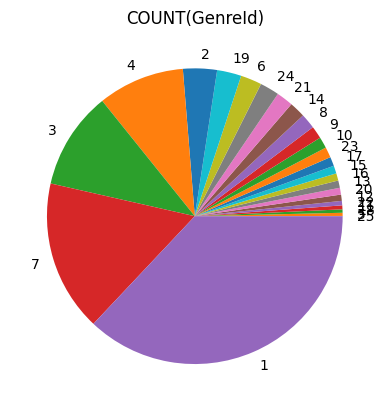

In [16]:

result = %sql select GenreId,COUNT(GenreId) from Track group by GenreId order by COUNT(GenreId);
%matplotlib inline
result.pie()

In [17]:
# cuantos album tenemos?
%%sql
select COUNT(DISTINCT(AlbumId)) as n_album from Track;


 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


n_album
347


In [18]:
#cantidad de albums con 10 y 20 canciones
%%sql
select count(AlbumId) as album_10_20 from (select AlbumId, count(trackid) as c_canciones
  from track
  group by AlbumId
  having c_canciones between 10 and 20
  order by c_canciones DESC);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


album_10_20
193


In [19]:
%%sql
select MIN(Milliseconds/1000) as corta,
AVG(Milliseconds/1000) as promedio,
MAX(Milliseconds/1000) as larga from Track;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


corta,promedio,larga
1,393.10191264630316,5286


In [20]:
%%sql
select AlbumId, count(trackid) as n_canciones, MIN(Milliseconds/1000) as corta,
AVG(Milliseconds/1000/60) as promedio,
MAX(Milliseconds/1000) as larga from Track
group by AlbumId
having n_canciones > 5
order by promedio DESC
 limit 20;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,n_canciones,corta,promedio,larga
253,24,2863,48.125,2960
227,19,2563,45.63157894736842,5286
229,26,2561,44.5,5088
231,24,2478,43.458333333333336,2825
228,23,2533,42.91304347826087,2687
230,25,2436,42.68,2631
261,17,112,38.23529411764706,2612
251,25,1268,25.16,2541
249,6,1306,21.833333333333332,1380
250,22,1237,21.318181818181817,1712


In [21]:
%%sql
select * from Track where AlbumId = 141;


 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
1702,Are You Gonna Go My Way,141,1,1,Craig Ross/Lenny Kravitz,211591,6905135,0.99
1703,Fly Away,141,1,1,Lenny Kravitz,221962,7322085,0.99
1704,Rock And Roll Is Dead,141,1,1,Lenny Kravitz,204199,6680312,0.99
1705,Again,141,1,1,Lenny Kravitz,228989,7490476,0.99
1706,It Ain't Over 'Til It's Over,141,1,1,Lenny Kravitz,242703,8078936,0.99
1707,Can't Get You Off My Mind,141,1,1,Lenny Kravitz,273815,8937150,0.99
1708,Mr. Cab Driver,141,1,1,Lenny Kravitz,230321,7668084,0.99
1709,American Woman,141,1,1,B. Cummings/G. Peterson/M.J. Kale/R. Bachman,261773,8538023,0.99
1710,Stand By My Woman,141,1,1,Henry Kirssch/Lenny Kravitz/S. Pasch A. Krizan,259683,8447611,0.99
1711,Always On The Run,141,1,1,Lenny Kravitz/Slash,232515,7593397,0.99


In [22]:
%%sql
select *, MIN(UnitPrice)  from track;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice,MIN(UnitPrice)
1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99,0.99


In [23]:
%%sql
select *, AVG(UnitPrice), MIN(UnitPrice), MAX(UnitPrice)  from track;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice,AVG(UnitPrice),MIN(UnitPrice),MAX(UnitPrice)
2819,Battlestar Galactica: The Story So Far,226,3,18,None,2622250,490750393,1.99,1.0508050242648312,0.99,1.99


In [24]:
%%sql
select AlbumId,
count(trackid) as n_canciones,
MIN(UnitPrice) as corta,
AVG(UnitPrice) as promedio,
MAX(UnitPrice) as larga,
SUM(UnitPrice) as t_album from Track
group by AlbumId
order by t_album DESC
 limit 20;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,n_canciones,corta,promedio,larga,t_album
141,57,0.99,0.9900000000000005,0.99,56.43000000000003
229,26,1.99,1.9900000000000004,1.99,51.74000000000001
230,25,1.99,1.9900000000000002,1.99,49.75000000000001
251,25,1.99,1.9900000000000002,1.99,49.75000000000001
231,24,1.99,1.9900000000000002,1.99,47.760000000000005
253,24,1.99,1.9900000000000002,1.99,47.760000000000005
228,23,1.99,1.9900000000000002,1.99,45.77
250,22,1.99,1.99,1.99,43.78
227,19,1.99,1.9899999999999998,1.99,37.809999999999995
261,17,1.99,1.9899999999999995,1.99,33.82999999999999


In [25]:

# contamos el numero listas
%%sql
select COUNT(DISTINCT PlaylistId) as cnt from PlaylistTrack;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


cnt
14


In [26]:
#contamos el numero de canciones por lista
%%sql
select PlaylistId,COUNT(TrackId) as cnt from  PlaylistTrack GROUP BY PlaylistId;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


PlaylistId,cnt
1,3290
3,213
5,1477
8,3290
9,1
10,213
11,39
12,75
13,25
14,25


In [27]:

%%sql
select PlaylistId,COUNT(TrackId) as cnt
from  PlaylistTrack
GROUP BY PlaylistId
HAVING cnt > 100;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


PlaylistId,cnt
1,3290
3,213
5,1477
8,3290
10,213


In [28]:
%%sql
select a.ArtistId, t.TrackId, al.AlbumId, al.Title, a.Name, t.Name
from album as al, Artist as a, track as t
where al.Artistid = a.Artistid and t.AlbumId = al.AlbumId order by a.ArtistId limit 10;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


ArtistId,TrackId,AlbumId,Title,Name,Name_1
1,1,1,For Those About To Rock We Salute You,AC/DC,For Those About To Rock (We Salute You)
1,6,1,For Those About To Rock We Salute You,AC/DC,Put The Finger On You
1,7,1,For Those About To Rock We Salute You,AC/DC,Let's Get It Up
1,8,1,For Those About To Rock We Salute You,AC/DC,Inject The Venom
1,9,1,For Those About To Rock We Salute You,AC/DC,Snowballed
1,10,1,For Those About To Rock We Salute You,AC/DC,Evil Walks
1,11,1,For Those About To Rock We Salute You,AC/DC,C.O.D.
1,12,1,For Those About To Rock We Salute You,AC/DC,Breaking The Rules
1,13,1,For Those About To Rock We Salute You,AC/DC,Night Of The Long Knives
1,14,1,For Those About To Rock We Salute You,AC/DC,Spellbound


In [29]:
%%sql
select *
from album join Artist using (Artistid) join track using (AlbumId)
order by ArtistId limit 1;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,Name,TrackId,Name_1,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
1,For Those About To Rock We Salute You,1,AC/DC,1,For Those About To Rock (We Salute You),1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99


In [30]:
%%sql
select * from track limit 1;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99


In [31]:
%%sql
select count(*)
from album as al, Artist as a, track as t
where al.Artistid = a.Artistid and t.AlbumId = al.AlbumId order by a.ArtistId limit 10;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


count(*)
3503


In [32]:

%%sql
select Name, Title as album_name
from album as al, Artist as a
where al.Artistid = a.Artistid and a.Name = "AC/DC";

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Name,album_name
AC/DC,For Those About To Rock We Salute You
AC/DC,Let There Be Rock


# Manipulando strings

In [33]:
%%sql
select distinct(composer) from track where composer like "%Brian";

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Composer
"May, Brian"
"Deacon, John/May, Brian"


In [34]:
%%sql
select distinct(composer) from track where composer like "Brian%";

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Composer
Brian Holland/Freddie Gorman/Georgia Dobbins/Robert Bateman/William Garrett
Brian May
Brian Holland/Eddie Holland/Lamont Dozier
"Brian Eno, Bono, Adam Clayton, The Edge & Larry Mullen Jnr."
Brian Eno/U2


In [35]:
%%sql
select distinct(composer) from track where composer like "%Brian%";

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Composer
"Angus Young, Malcolm Young, Brian Johnson"
Brian Holland/Freddie Gorman/Georgia Dobbins/Robert Bateman/William Garrett
Brian May
Brian Holland/Eddie Holland/Lamont Dozier
"Brian Eno, Bono, Adam Clayton, The Edge & Larry Mullen Jnr."
"May, Brian"
"Deacon, John/May, Brian"
Brian Eno/U2


In [36]:

%%sql
select distinct(composer) from track where composer like "%Br_an%";

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Composer
"Angus Young, Malcolm Young, Brian Johnson"
Brian Holland/Freddie Gorman/Georgia Dobbins/Robert Bateman/William Garrett
Brian May
Brian Holland/Eddie Holland/Lamont Dozier
Bryan Adams/Nikki Sixx/Scott Humphrey
"Brian Eno, Bono, Adam Clayton, The Edge & Larry Mullen Jnr."
"May, Brian"
"Deacon, John/May, Brian"
Brian Eno/U2


In [37]:

%%sql
select length(distinct(composer)) from track where composer like "%Br_an%" limit 2;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


length(distinct(composer))
41
41


In [38]:
%%sql
select upper(distinct(composer)) from track where composer like "%Br_an%" limit 2;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


upper(distinct(composer))
"ANGUS YOUNG, MALCOLM YOUNG, BRIAN JOHNSON"
"ANGUS YOUNG, MALCOLM YOUNG, BRIAN JOHNSON"


In [39]:
%%sql
select substr(distinct(composer),1,6) from track where composer like "%Br_an%" limit 2;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


"substr(distinct(composer),1,6)"
Angus
Angus


In [40]:
%%sql
select replace(distinct(composer),"Angus","Alex") from track where composer like "%Br_an%" limit 2;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


"replace(distinct(composer),""Angus"",""Alex"")"
"Alex Young, Malcolm Young, Brian Johnson"
"Alex Young, Malcolm Young, Brian Johnson"


# controlando resultados

In [41]:
%%sql
select Name,Milliseconds from track
order by Milliseconds ASC limit 3;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Name,Milliseconds
É Uma Partida De Futebol,1071
Now Sports,4884
A Statistic,6373


In [42]:

%%sql
select Name,Milliseconds from track
order by Milliseconds DESC limit 3;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Name,Milliseconds
Occupation / Precipice,5286953
Through a Looking Glass,5088838
"Greetings from Earth, Pt. 1",2960293


In [43]:
%%sql
select * from track
order by MediaTypeId DESC, GenreId ASC, AlbumId DESC limit 10;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
3355,Love Comes,265,5,1,"Darius ""Take One"" Minwalla/Jon Auer/Ken Stringfellow/Matt Harris",199923,3240609,0.99
3353,I Guess You're Right,265,5,1,"Darius ""Take One"" Minwalla/Jon Auer/Ken Stringfellow/Matt Harris",212044,3453849,0.99
3357,OAM's Blues,267,5,2,Aaron Goldberg,266936,4292028,0.99
3350,Despertar,262,5,2,Andrea Dulbecco,307385,4821485,0.99
3349,Amanda,262,5,2,Luca Gusella,246503,4011615,0.99
3356,Muita Bobeira,266,5,7,Luciana Souza,172710,2775071,0.99
3358,One Step Beyond,264,5,15,Karsh Kale,366085,6034098,0.99
3352,Distance,264,5,15,Karsh Kale/Vishal Vaid,327122,5327463,0.99
3354,I Ka Barra (Your Work),263,5,16,Habib Koité,300605,4855457,0.99
3351,Din Din Wo (Little Child),263,5,16,Habib Koité,285837,4615841,0.99


In [44]:

%%sql
select * from track limit 5 offset 10

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
11,C.O.D.,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",199836,6566314,0.99
12,Breaking The Rules,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",263288,8596840,0.99
13,Night Of The Long Knives,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",205688,6706347,0.99
14,Spellbound,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",270863,8817038,0.99
15,Go Down,4,1,1,AC/DC,331180,10847611,0.99


Manipulacion de Fechas y Horas

In [45]:
%%sql
PRAGMA table_info([invoice]);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


cid,name,type,notnull,dflt_value,pk
0,InvoiceId,INTEGER,1,None,1
1,CustomerId,INTEGER,1,None,0
2,InvoiceDate,DATETIME,1,None,0
3,BillingAddress,NVARCHAR(70),0,None,0
4,BillingCity,NVARCHAR(40),0,None,0
5,BillingState,NVARCHAR(40),0,None,0
6,BillingCountry,NVARCHAR(40),0,None,0
7,BillingPostalCode,NVARCHAR(10),0,None,0
8,Total,"NUMERIC(10,2)",1,None,0


In [46]:
%%sql
select  InvoiceDate,strftime('%Y',InvoiceDate) as "Año",
strftime('%m',InvoiceDate) as "Mes",
strftime('%d',InvoiceDate) as "Dia",
strftime('%H',InvoiceDate) as "Horas",
strftime('%M',InvoiceDate) as "Minutos"
 from invoice limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


InvoiceDate,Año,Mes,Dia,Horas,Minutos
2021-01-01 00:00:00,2021,01,01,00,00
2021-01-02 00:00:00,2021,01,02,00,00
2021-01-03 00:00:00,2021,01,03,00,00
2021-01-06 00:00:00,2021,01,06,00,00
2021-01-11 00:00:00,2021,01,11,00,00


In [47]:

%%sql
select  InvoiceDate,strftime('%Y',InvoiceDate) as "Año",
strftime('%m',InvoiceDate) as "Mes",
strftime('%d',InvoiceDate) as Dia
 from invoice where Dia in ("01","02","11") limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


InvoiceDate,Año,Mes,Dia
2021-01-01 00:00:00,2021,01,01
2021-01-02 00:00:00,2021,01,02
2021-01-11 00:00:00,2021,01,11
2021-02-01 00:00:00,2021,02,01
2021-02-01 00:00:00,2021,02,01


In [48]:
%%sql
select strftime('%Y',InvoiceDate) as "Año",
strftime('%m',InvoiceDate) as "Mes",
strftime('%d',InvoiceDate) as "Dia"
 from invoice limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Año,Mes,Dia
2021,01,01
2021,01,02
2021,01,03
2021,01,06
2021,01,11


Subconsultas

In [49]:
%%sql
select name , AlbumId
from track
where AlbumId in (
  select AlbumId
  from album
  where title = "Californication")
limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Name,AlbumId
Around The World,195
Parallel Universe,195
Scar Tissue,195
Otherside,195
Get On Top,195


In [50]:

%%sql
select name , AlbumId
from track
where AlbumId not in (
  select AlbumId
  from album
  where title = "Californication")
limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Name,AlbumId
For Those About To Rock (We Salute You),1
Balls to the Wall,2
Fast As a Shark,3
Restless and Wild,3
Princess of the Dawn,3


In [51]:
%%sql
select * from album, track where album.albumid==track.albumid and album.title=="Californication";

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,TrackId,Name,AlbumId_1,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
195,Californication,127,2391,Around The World,195,1,1,Anthony Kiedis/Chad Smith/Flea/John Frusciante,238837,7859167,0.99
195,Californication,127,2392,Parallel Universe,195,1,1,Red Hot Chili Peppers,270654,8958519,0.99
195,Californication,127,2393,Scar Tissue,195,1,1,Red Hot Chili Peppers,217469,7153744,0.99
195,Californication,127,2394,Otherside,195,1,1,Red Hot Chili Peppers,255973,8357989,0.99
195,Californication,127,2395,Get On Top,195,1,1,Red Hot Chili Peppers,198164,6587883,0.99
195,Californication,127,2396,Californication,195,1,1,Red Hot Chili Peppers,321671,10568999,0.99
195,Californication,127,2397,Easily,195,1,1,Red Hot Chili Peppers,231418,7504534,0.99
195,Californication,127,2398,Porcelain,195,1,1,Anthony Kiedis/Chad Smith/Flea/John Frusciante,163787,5278793,0.99
195,Californication,127,2399,Emit Remmus,195,1,1,Red Hot Chili Peppers,240300,7901717,0.99
195,Californication,127,2400,I Like Dirt,195,1,1,Red Hot Chili Peppers,157727,5225917,0.99


In [52]:
%%sql
select * from album, track where album.albumid==track.albumid and album.albumid==195;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,TrackId,Name,AlbumId_1,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
195,Californication,127,2391,Around The World,195,1,1,Anthony Kiedis/Chad Smith/Flea/John Frusciante,238837,7859167,0.99
195,Californication,127,2392,Parallel Universe,195,1,1,Red Hot Chili Peppers,270654,8958519,0.99
195,Californication,127,2393,Scar Tissue,195,1,1,Red Hot Chili Peppers,217469,7153744,0.99
195,Californication,127,2394,Otherside,195,1,1,Red Hot Chili Peppers,255973,8357989,0.99
195,Californication,127,2395,Get On Top,195,1,1,Red Hot Chili Peppers,198164,6587883,0.99
195,Californication,127,2396,Californication,195,1,1,Red Hot Chili Peppers,321671,10568999,0.99
195,Californication,127,2397,Easily,195,1,1,Red Hot Chili Peppers,231418,7504534,0.99
195,Californication,127,2398,Porcelain,195,1,1,Anthony Kiedis/Chad Smith/Flea/John Frusciante,163787,5278793,0.99
195,Californication,127,2399,Emit Remmus,195,1,1,Red Hot Chili Peppers,240300,7901717,0.99
195,Californication,127,2400,I Like Dirt,195,1,1,Red Hot Chili Peppers,157727,5225917,0.99


In [53]:
%%sql
select * from album as a, track as t
where a.albumid==t.albumid and a.albumid==195
order by  t.milliseconds limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,TrackId,Name,AlbumId_1,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
195,Californication,127,2404,Right On Time,195,1,1,Red Hot Chili Peppers,112613,3722219,0.99
195,Californication,127,2400,I Like Dirt,195,1,1,Red Hot Chili Peppers,157727,5225917,0.99
195,Californication,127,2398,Porcelain,195,1,1,Anthony Kiedis/Chad Smith/Flea/John Frusciante,163787,5278793,0.99
195,Californication,127,2395,Get On Top,195,1,1,Red Hot Chili Peppers,198164,6587883,0.99
195,Californication,127,2405,Road Trippin',195,1,1,Red Hot Chili Peppers,205635,6685831,0.99


In [54]:
%%sql
select Title, Name, Composer from Album,track where Album.albumid==track.albumid and Album.Title=="Californication";

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Title,Name,Composer
Californication,Around The World,Anthony Kiedis/Chad Smith/Flea/John Frusciante
Californication,Parallel Universe,Red Hot Chili Peppers
Californication,Scar Tissue,Red Hot Chili Peppers
Californication,Otherside,Red Hot Chili Peppers
Californication,Get On Top,Red Hot Chili Peppers
Californication,Californication,Red Hot Chili Peppers
Californication,Easily,Red Hot Chili Peppers
Californication,Porcelain,Anthony Kiedis/Chad Smith/Flea/John Frusciante
Californication,Emit Remmus,Red Hot Chili Peppers
Californication,I Like Dirt,Red Hot Chili Peppers


In [55]:
%%sql
select name , AlbumId
from track
where AlbumId in (
  select AlbumId
  from album
  where title = "Californication")

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Name,AlbumId
Around The World,195
Parallel Universe,195
Scar Tissue,195
Otherside,195
Get On Top,195
Californication,195
Easily,195
Porcelain,195
Emit Remmus,195
I Like Dirt,195


In [56]:
%%sql
select FirstName,
        LastName,
        City,
        Email,
        customer.CustomerId,
        InvoiceDate,
        BillingAddress,
        Total,
        InvoiceId
from customer, invoice
where customer.CustomerId==59 and invoice.customerId=customer.customerId
order by Total

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


FirstName,LastName,City,Email,CustomerId,InvoiceDate,BillingAddress,Total,InvoiceId
Puja,Srivastava,Bangalore,puja_srivastava@yahoo.in,59,2023-08-20 00:00:00,"3,Raj Bhavan Road",1.98,218
Puja,Srivastava,Bangalore,puja_srivastava@yahoo.in,59,2022-02-26 00:00:00,"3,Raj Bhavan Road",1.99,97
Puja,Srivastava,Bangalore,puja_srivastava@yahoo.in,59,2021-04-05 00:00:00,"3,Raj Bhavan Road",3.96,23
Puja,Srivastava,Bangalore,puja_srivastava@yahoo.in,59,2021-07-08 00:00:00,"3,Raj Bhavan Road",5.94,45
Puja,Srivastava,Bangalore,puja_srivastava@yahoo.in,59,2024-05-30 00:00:00,"3,Raj Bhavan Road",8.91,284
Puja,Srivastava,Bangalore,puja_srivastava@yahoo.in,59,2023-09-30 00:00:00,"3,Raj Bhavan Road",13.86,229


In [57]:
%%sql
select * from track where trackid in (
select TrackId from InvoiceLine where invoiceId==229);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
517,Um Indio,23,1,7,None,195944,6453213,0.99
526,Fora Da Ordem,23,1,7,None,354011,11746781,0.99
535,Chão De Estrelas,42,1,4,Orestes Barbosa-Sílvio Caldas,284813,9433620,0.99
544,Stormbringer,43,1,1,Coverdale,277133,9050022,0.99
553,Houses Of The Holy,44,1,1,Jimmy Page/Robert Plant,242494,7972503,0.99
562,Mangueira,45,1,7,Bizuca/Clóvis Pê/Gilson Bernini/Marelo D'Aguia,298318,9999506,0.99
571,Love Of My Life,46,1,1,Carlos Santana & Dave Matthews,347820,11634337,0.99
580,El Farol,46,1,1,Carlos Santana & KC Porter,291160,9599353,0.99
589,Um Love,47,1,7,None,181603,6095524,0.99
598,Jeru,48,1,2,Miles Davis,193410,6222536,0.99


In [58]:
%%sql
select FirstName,
        LastName,
        City,
        Email,
        customer.CustomerId,
        count(invoice.CustomerId) as Total_Invoices
from customer , invoice
where customer.CustomerId = invoice.CustomerId
Group by customer.customerId
order by Total_Invoices DESC

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


FirstName,LastName,City,Email,CustomerId,Total_Invoices
Luís,Gonçalves,São José dos Campos,luisg@embraer.com.br,1,7
Leonie,Köhler,Stuttgart,leonekohler@surfeu.de,2,7
François,Tremblay,Montréal,ftremblay@gmail.com,3,7
Bjørn,Hansen,Oslo,bjorn.hansen@yahoo.no,4,7
František,Wichterlová,Prague,frantisekw@jetbrains.com,5,7
Helena,Holý,Prague,hholy@gmail.com,6,7
Astrid,Gruber,Vienne,astrid.gruber@apple.at,7,7
Daan,Peeters,Brussels,daan_peeters@apple.be,8,7
Kara,Nielsen,Copenhagen,kara.nielsen@jubii.dk,9,7
Eduardo,Martins,São Paulo,eduardo@woodstock.com.br,10,7


Consultas avanzadas

In [59]:
%%sql
SELECT c.FirstName || ' ' || c.LastName AS CustomerName,
       (SELECT COUNT(*) FROM invoiceline WHERE InvoiceId IN
           (SELECT InvoiceId FROM invoice WHERE CustomerId = c.CustomerId)) AS TotalTracksPurchased,
       (SELECT COUNT(DISTINCT AlbumId) FROM
           (SELECT AlbumId FROM invoiceline INNER JOIN track ON invoiceline.TrackId = track.TrackId
            WHERE InvoiceId IN (SELECT InvoiceId FROM invoice WHERE CustomerId = c.CustomerId))) AS TotalAlbumsPurchased,
       (SELECT SUM(Total) FROM invoice WHERE CustomerId = c.CustomerId) AS TotalSpent
FROM customer c;


 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


CustomerName,TotalTracksPurchased,TotalAlbumsPurchased,TotalSpent
Luís Gonçalves,38,22,39.62
Leonie Köhler,38,22,37.620000000000005
François Tremblay,38,26,39.62
Bjørn Hansen,38,25,39.62
František Wichterlová,38,22,40.620000000000005
Helena Holý,38,19,49.620000000000005
Astrid Gruber,38,21,42.62
Daan Peeters,38,19,37.62
Kara Nielsen,38,20,37.620000000000005
Eduardo Martins,38,25,37.620000000000005


# Joins

In [60]:
%%sql
select * from album CROSS JOIN Artist limit 10;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,ArtistId_1,Name
1,For Those About To Rock We Salute You,1,1,AC/DC
1,For Those About To Rock We Salute You,1,2,Accept
1,For Those About To Rock We Salute You,1,3,Aerosmith
1,For Those About To Rock We Salute You,1,4,Alanis Morissette
1,For Those About To Rock We Salute You,1,5,Alice In Chains
1,For Those About To Rock We Salute You,1,6,Antônio Carlos Jobim
1,For Those About To Rock We Salute You,1,7,Apocalyptica
1,For Those About To Rock We Salute You,1,8,Audioslave
1,For Those About To Rock We Salute You,1,9,BackBeat
1,For Those About To Rock We Salute You,1,10,Billy Cobham


In [61]:
%%sql
select count(*) from album JOIN Artist ON album.artistId=Artist.artistId limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


count(*)
347


In [62]:
%%sql
select * from album  JOIN Artist USING (artistId) limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,Name
1,For Those About To Rock We Salute You,1,AC/DC
2,Balls to the Wall,2,Accept
3,Restless and Wild,2,Accept
4,Let There Be Rock,1,AC/DC
5,Big Ones,3,Aerosmith


In [63]:
%%sql
select * from album  NATURAL JOIN Artist limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,Name
1,For Those About To Rock We Salute You,1,AC/DC
2,Balls to the Wall,2,Accept
3,Restless and Wild,2,Accept
4,Let There Be Rock,1,AC/DC
5,Big Ones,3,Aerosmith


In [64]:

%%sql
select * from album, Artist WHERE album.artistId=Artist.artistId limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,ArtistId_1,Name
1,For Those About To Rock We Salute You,1,1,AC/DC
2,Balls to the Wall,2,2,Accept
3,Restless and Wild,2,2,Accept
4,Let There Be Rock,1,1,AC/DC
5,Big Ones,3,3,Aerosmith


In [65]:
%%sql
select * from album  LEFT OUTER JOIN Artist USING (artistId) limit 10;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,Name
1,For Those About To Rock We Salute You,1,AC/DC
2,Balls to the Wall,2,Accept
3,Restless and Wild,2,Accept
4,Let There Be Rock,1,AC/DC
5,Big Ones,3,Aerosmith
6,Jagged Little Pill,4,Alanis Morissette
7,Facelift,5,Alice In Chains
8,Warner 25 Anos,6,Antônio Carlos Jobim
9,Plays Metallica By Four Cellos,7,Apocalyptica
10,Audioslave,8,Audioslave


In [66]:
%%sql
select * from album  RIGHT OUTER JOIN Artist limit 10;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
(sqlite3.OperationalError) RIGHT and FULL OUTER JOINs are not currently supported
[SQL: select * from album  RIGHT OUTER JOIN Artist limit 10;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [67]:
%%sql
select * from album  JOIN Artist USING (artistId) JOIN Track USING (albumid) limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,Name,TrackId,Name_1,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
1,For Those About To Rock We Salute You,1,AC/DC,1,For Those About To Rock (We Salute You),1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
2,Balls to the Wall,2,Accept,2,Balls to the Wall,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Baltes, S. Kaufmann, G. Hoffmann",342562,5510424,0.99
3,Restless and Wild,2,Accept,3,Fast As a Shark,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Hoffman",230619,3990994,0.99
3,Restless and Wild,2,Accept,4,Restless and Wild,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. Dirkscneider & W. Hoffman",252051,4331779,0.99
3,Restless and Wild,2,Accept,5,Princess of the Dawn,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99


In [68]:
%%sql
select * from album  NATURAL JOIN Artist  limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,Name
1,For Those About To Rock We Salute You,1,AC/DC
2,Balls to the Wall,2,Accept
3,Restless and Wild,2,Accept
4,Let There Be Rock,1,AC/DC
5,Big Ones,3,Aerosmith


In [69]:
%%sql
select * from album NATURAL JOIN (select * from Artist) limit 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId,Name
1,For Those About To Rock We Salute You,1,AC/DC
2,Balls to the Wall,2,Accept
3,Restless and Wild,2,Accept
4,Let There Be Rock,1,AC/DC
5,Big Ones,3,Aerosmith


In [70]:

%%sql
select Name,Milliseconds from track
order by Milliseconds DESC limit 3;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Name,Milliseconds
Occupation / Precipice,5286953
Through a Looking Glass,5088838
"Greetings from Earth, Pt. 1",2960293


In [71]:
%%sql
select * from track
order by MediaTypeId DESC, GenreId ASC, AlbumId DESC limit 10;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
3355,Love Comes,265,5,1,"Darius ""Take One"" Minwalla/Jon Auer/Ken Stringfellow/Matt Harris",199923,3240609,0.99
3353,I Guess You're Right,265,5,1,"Darius ""Take One"" Minwalla/Jon Auer/Ken Stringfellow/Matt Harris",212044,3453849,0.99
3357,OAM's Blues,267,5,2,Aaron Goldberg,266936,4292028,0.99
3350,Despertar,262,5,2,Andrea Dulbecco,307385,4821485,0.99
3349,Amanda,262,5,2,Luca Gusella,246503,4011615,0.99
3356,Muita Bobeira,266,5,7,Luciana Souza,172710,2775071,0.99
3358,One Step Beyond,264,5,15,Karsh Kale,366085,6034098,0.99
3352,Distance,264,5,15,Karsh Kale/Vishal Vaid,327122,5327463,0.99
3354,I Ka Barra (Your Work),263,5,16,Habib Koité,300605,4855457,0.99
3351,Din Din Wo (Little Child),263,5,16,Habib Koité,285837,4615841,0.99


In [72]:
%%sql
select FirstName,
        LastName,
        City,
        Email,
        customer.CustomerId,
        count(invoice.CustomerId) as Total_Invoices
from customer , invoice
where customer.CustomerId = invoice.CustomerId
Group by customer.customerId
order by Total_Invoices DESC

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


FirstName,LastName,City,Email,CustomerId,Total_Invoices
Luís,Gonçalves,São José dos Campos,luisg@embraer.com.br,1,7
Leonie,Köhler,Stuttgart,leonekohler@surfeu.de,2,7
François,Tremblay,Montréal,ftremblay@gmail.com,3,7
Bjørn,Hansen,Oslo,bjorn.hansen@yahoo.no,4,7
František,Wichterlová,Prague,frantisekw@jetbrains.com,5,7
Helena,Holý,Prague,hholy@gmail.com,6,7
Astrid,Gruber,Vienne,astrid.gruber@apple.at,7,7
Daan,Peeters,Brussels,daan_peeters@apple.be,8,7
Kara,Nielsen,Copenhagen,kara.nielsen@jubii.dk,9,7
Eduardo,Martins,São Paulo,eduardo@woodstock.com.br,10,7
